In [35]:
import os
import re
import glob
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# Konfiguracja stylu wykresów
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.dpi'] = 120


In [36]:
def parse_perf_file(filepath):
    """Parsuje plik perf_cpu_stats.txt i zwraca słownik z metrykami."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()

    data = {}
    time_m = re.search(r"([\d\.,]+)\s+seconds time elapsed", content)
    if time_m:
        data["time"] = float(time_m.group(1).replace(",", "."))

    cyc_m = re.search(r"([\d\s\.,]+)\s+cycles", content)
    if cyc_m:
        data["cycles"] = int(cyc_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))

    inst_m = re.search(r"([\d\s\.,]+)\s+instructions", content)
    if inst_m:
        data["instructions"] = int(inst_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))

    ipc_m = re.search(r"#\s+([\d\.,]+)\s+insn per cycle", content)
    if ipc_m:
        data["ipc"] = float(ipc_m.group(1).replace(",", "."))

    l1_miss_m = re.search(r"([\d\s\.,]+)\s+L1-dcache-load-misses", content)
    if l1_miss_m:
        data["l1_misses"] = int(l1_miss_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))
    l1_load_m = re.search(r"([\d\s\.,]+)\s+L1-dcache-loads", content)
    if l1_load_m:
        data["l1_loads"] = int(l1_load_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))
    if "l1_misses" in data and "l1_loads" in data and data["l1_loads"] > 0:
        data["l1_miss_rate"] = (data["l1_misses"] / data["l1_loads"]) * 100.0

    br_miss_m = re.search(r"([\d\s\.,]+)\s+branch-misses", content)
    if br_miss_m:
        data["branch_misses"] = int(br_miss_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))
    br_load_m = re.search(r"([\d\s\.,]+)\s+branch-loads", content)
    if br_load_m:
        data["branch_loads"] = int(br_load_m.group(1).replace(" ", "").replace(".", "").replace(",", ""))
    if "branch_misses" in data and "branch_loads" in data and data["branch_loads"] > 0:
        data["branch_miss_rate"] = (data["branch_misses"] / data["branch_loads"]) * 100.0

    return data


In [37]:
# Wyszukiwanie folderów i parsowanie wszystkich prób
base_path = "hpc_logs" if os.path.exists("hpc_logs") else "plots/hpc_logs"
scaling_cores = [1, 2, 4, 8, 16, 32, 64]

implementations = {
    "C++ OpenMP": {
        "pattern": f"{base_path}/C-OMP/STAT/*/edupic_data/perf_cpu_stats.txt",
        "color": "#1f77b4",
        "style": "o-"
    },
    "Go Chunking": {
        "pattern": f"{base_path}/Go-Chunking/STAT/*/edupic_data/perf_cpu_stats.txt",
        "color": "#2ca02c",
        "style": "s-"
    },
    "Go Chunking 2x": {
        "pattern": f"{base_path}/Go-Chunking/STAT-2/*/edupic_data/perf_cpu_stats.txt",
        "color": "#07f1de",
        "style": "P-"
    },
    "Go Chunking 10x": {
        "pattern": f"{base_path}/Go-Chunking/STAT-10/*/edupic_data/perf_cpu_stats.txt",
        "color": "#e70a0a",
        "style": "v-"
    },
    "Go Channels": {
        "pattern": f"{base_path}/Go-Channels/STAT/*/edupic_data/perf_cpu_stats.txt",
        "color": "#ff7f0e",
        "style": "^-"
    },
    "Go Channels 2x": {
        "pattern": f"{base_path}/Go-Channels/STAT-2/*/edupic_data/perf_cpu_stats.txt",
        "color": "#7505f5",
        "style": "*-"
    },
    "Go Channels 10x": {
        "pattern": f"{base_path}/Go-Channels/STAT-10/*/edupic_data/perf_cpu_stats.txt",
        "color": "#e00ae7",
        "style": ">-"
    }
}

# raw_trials[impl][cores] = [ { 'time': ..., 'ipc': ..., 'trial': ... }, ... ]
raw_trials = defaultdict(lambda: defaultdict(list))

for name, conf in implementations.items():
    files = sorted(glob.glob(conf["pattern"]))
    for f in files:
        run_folder = os.path.basename(os.path.dirname(os.path.dirname(f)))
        # Wyodrębnienie liczby rdzeni oraz numeru próby: np. OMP_STAT-1_2 lub CHUNKING_STAT-1-1
        m = re.search(r'[-_](\d+)[-_](\d+)', run_folder)
        if m:
            cores = int(m.group(1))
            trial = int(m.group(2))
        else:
            # Fallback np. OMP_STAT-1
            m_single = re.search(r'[-_](\d+)', run_folder)
            if m_single:
                cores = int(m_single.group(1))
                trial = 1
            else:
                continue
        
        data = parse_perf_file(f)
        data["run_folder"] = run_folder
        data["trial"] = trial
        raw_trials[name][cores].append(data)

print("Wczytane serie pomiarowe i liczba prób:")
for name in implementations.keys():
    cores_summary = {c: len(raw_trials[name][c]) for c in sorted(raw_trials[name].keys())}
    if cores_summary:
        print(f"  {name}: {cores_summary}")


Wczytane serie pomiarowe i liczba prób:
  C++ OpenMP: {1: 3, 2: 3, 4: 3, 8: 3, 16: 3, 32: 3, 64: 3}


In [38]:
# Obliczanie średnich, odchyleń standardowych, przyspieszenia i efektywności
stats_summary = {}

for name, conf in implementations.items():
    if name not in raw_trials or len(raw_trials[name]) == 0:
        continue
    
    stats_summary[name] = {
        "cores": [],
        "trials_count": [],
        "time_avg": [], "time_min": [], "time_max": [], "time_std": [],
        "all_times": [], "all_cores_expanded": [],
        "speedup_avg": [], "speedup_max": [], "efficiency_avg": [],
        "ipc_avg": [], "instructions_avg": [], "cycles_avg": [],
        "l1_miss_rate_avg": [], "branch_miss_rate_avg": [],
        "color": conf["color"],
        "style": conf["style"]
    }
    
    # Wyznaczenie czasu bazowego T1 (średnia dla 1 rdzenia danej implementacji)
    t1_list = [d["time"] for d in raw_trials[name].get(1, []) if "time" in d]
    t1_avg = np.mean(t1_list) if len(t1_list) > 0 else None
    
    for c in scaling_cores:
        trials = raw_trials[name].get(c, [])
        if not trials:
            continue
            
        times = [d["time"] for d in trials if "time" in d]
        if not times:
            continue
            
        t_avg = float(np.mean(times))
        t_min = float(np.min(times))
        t_max = float(np.max(times))
        t_std = float(np.std(times)) if len(times) > 1 else 0.0
        
        sp_avg = (t1_avg / t_avg) if t1_avg else 1.0
        sp_max = (t1_avg / t_min) if t1_avg else 1.0
        eff_avg = (sp_avg / c) * 100.0
        
        ipcs = [d["ipc"] for d in trials if "ipc" in d]
        insns = [d["instructions"] / 1e9 for d in trials if "instructions" in d]
        cycs = [d["cycles"] / 1e9 for d in trials if "cycles" in d]
        l1_misses = [d["l1_miss_rate"] for d in trials if "l1_miss_rate" in d]
        br_misses = [d["branch_miss_rate"] for d in trials if "branch_miss_rate" in d]
        
        stats_summary[name]["cores"].append(c)
        stats_summary[name]["trials_count"].append(len(times))
        stats_summary[name]["time_avg"].append(t_avg)
        stats_summary[name]["time_min"].append(t_min)
        stats_summary[name]["time_max"].append(t_max)
        stats_summary[name]["time_std"].append(t_std)
        stats_summary[name]["speedup_avg"].append(sp_avg)
        stats_summary[name]["speedup_max"].append(sp_max)
        stats_summary[name]["efficiency_avg"].append(eff_avg)
        stats_summary[name]["ipc_avg"].append(np.mean(ipcs) if ipcs else 0.0)
        stats_summary[name]["instructions_avg"].append(np.mean(insns) if insns else 0.0)
        stats_summary[name]["cycles_avg"].append(np.mean(cycs) if cycs else 0.0)
        stats_summary[name]["l1_miss_rate_avg"].append(np.mean(l1_misses) if l1_misses else 0.0)
        stats_summary[name]["branch_miss_rate_avg"].append(np.mean(br_misses) if br_misses else 0.0)
        
        # Zachowanie wszystkich pojedynczych prób do wykresów punktowych
        for t_val in times:
            stats_summary[name]["all_cores_expanded"].append(c)
            stats_summary[name]["all_times"].append(t_val)

# Tabela wyników ze statystykami prób
header = f"{'Implementacja':<15} | {'Rdzenie':<7} | {'Próby':<5} | {'Czas śr [s]':<11} | {'Czas min [s]':<12} | {'StdDev [s]':<10} | {'Speedup śr':<10} | {'Efekt. [%]':<10} | {'IPC':<5} | {'Instrukcje [mld]':<17}"
print(header)
print("-" * len(header))
for name, s in stats_summary.items():
    for i, c in enumerate(s["cores"]):
        row = f"{name:<15} | {c:<7} | {s['trials_count'][i]:<5} | {s['time_avg'][i]:<11.2f} | {s['time_min'][i]:<12.2f} | {s['time_std'][i]:<10.2f} | {s['speedup_avg'][i]:<10.2f} | {s['efficiency_avg'][i]:<10.1f}% | {s['ipc_avg'][i]:<5.2f} | {s['instructions_avg'][i]:<17.2f}"
        print(row)
    print("-" * len(header))


Implementacja   | Rdzenie | Próby | Czas śr [s] | Czas min [s] | StdDev [s] | Speedup śr | Efekt. [%] | IPC   | Instrukcje [mld] 
---------------------------------------------------------------------------------------------------------------------------------
C++ OpenMP      | 1       | 3     | 142.42      | 138.37       | 4.22       | 1.00       | 100.0     % | 3.69  | 1867.93          
C++ OpenMP      | 2       | 3     | 77.70       | 75.11        | 1.85       | 1.83       | 91.6      % | 3.49  | 1879.20          
C++ OpenMP      | 4       | 3     | 40.83       | 40.23        | 0.82       | 3.49       | 87.2      % | 3.24  | 1880.69          
C++ OpenMP      | 8       | 3     | 24.98       | 22.71        | 3.18       | 5.70       | 71.3      % | 2.64  | 1896.04          
C++ OpenMP      | 16      | 3     | 16.60       | 16.38        | 0.28       | 8.58       | 53.6      % | 1.98  | 1922.07          
C++ OpenMP      | 32      | 3     | 14.30       | 13.89        | 0.50       | 9.96   

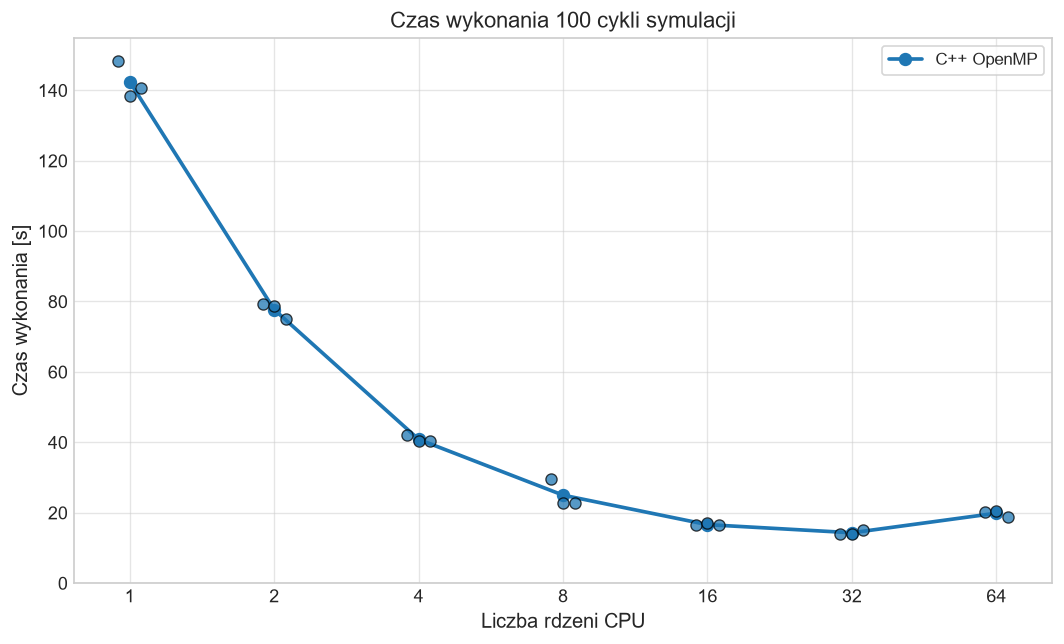

In [39]:
# Wykres 1: Czas wykonania (Średnia + pojedyncze próby)
fig, ax = plt.subplots(figsize=(9, 5.5))

x_pos = {c: i for i, c in enumerate(scaling_cores)}

for label, s in stats_summary.items():
    xs = [x_pos[c] for c in s["cores"]]
    
    # 1. Linia średniej
    ax.plot(xs, s["time_avg"], s["style"], color=s["color"], label=label, linewidth=2.2, markersize=7, zorder=3)
    
    # 2. Próbki lekko rozsunięte w poziomie, aby było widać każdą z nich
    for c in s["cores"]:
        trials = raw_trials[label][c]
        n_tr = len(trials)
        times = [d["time"] for d in trials if "time" in d]
        offsets = np.linspace(-0.08, 0.08, n_tr) if n_tr > 1 else [0.0]
        
        c_x = x_pos[c]
        for off, t_val in zip(offsets, times):
            ax.scatter(c_x + off, t_val, color=s["color"], s=45, edgecolors='black', linewidths=0.8, alpha=0.75, zorder=4)

ax.set_xlabel("Liczba rdzeni CPU")
ax.set_ylabel("Czas wykonania [s]")
ax.set_title("Czas wykonania 100 cykli symulacji")
ax.set_xticks(range(len(scaling_cores)))
ax.set_xticklabels(scaling_cores)
ax.set_ylim(bottom=0)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()


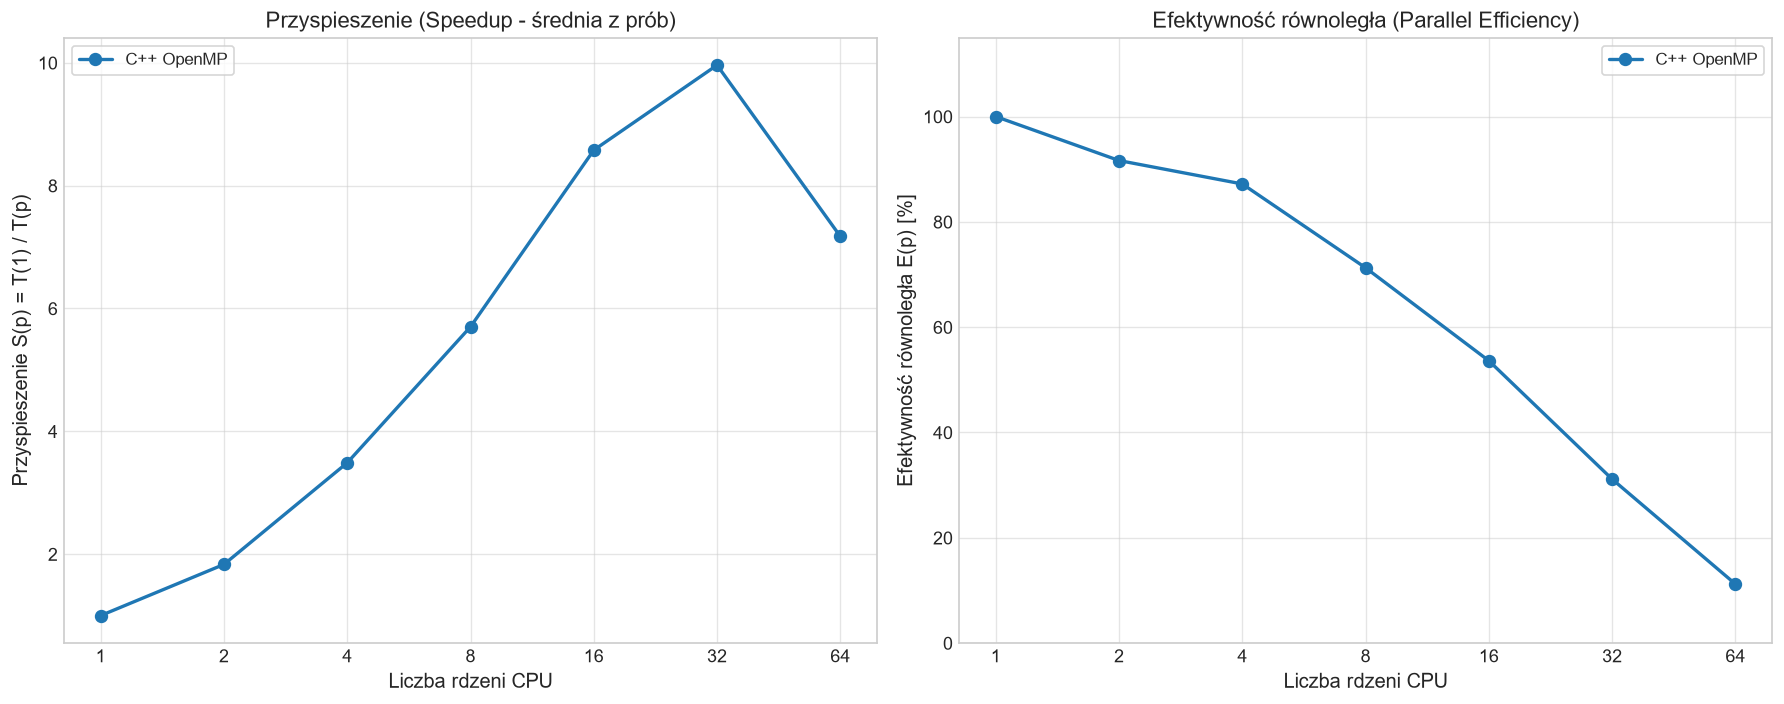

In [40]:
# Wykres 2: Przyspieszenie (Speedup) oraz Efektywność równoległa (Parallel Efficiency)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

x_pos = {c: i for i, c in enumerate(scaling_cores)}
xs_all = range(len(scaling_cores))

# Subplot 1: Speedup
for label, s in stats_summary.items():
    xs = [x_pos[c] for c in s["cores"]]
    ax1.plot(xs, s["speedup_avg"], s["style"], color=s["color"], label=f"{label}", linewidth=2, markersize=7)

ax1.set_xlabel("Liczba rdzeni CPU")
ax1.set_ylabel("Przyspieszenie S(p) = T(1) / T(p)")
ax1.set_title("Przyspieszenie (Speedup - średnia z prób)")
ax1.set_xticks(range(len(scaling_cores)))
ax1.set_xticklabels(scaling_cores)
ax1.legend(frameon=True)

# Subplot 2: Parallel Efficiency
for label, s in stats_summary.items():
    xs = [x_pos[c] for c in s["cores"]]
    ax2.plot(xs, s["efficiency_avg"], s["style"], color=s["color"], label=f"{label}", linewidth=2, markersize=7)

ax2.set_xlabel("Liczba rdzeni CPU")
ax2.set_ylabel("Efektywność równoległa E(p) [%]")
ax2.set_title("Efektywność równoległa (Parallel Efficiency)")
ax2.set_xticks(range(len(scaling_cores)))
ax2.set_xticklabels(scaling_cores)
ax2.set_ylim(0, 115)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()


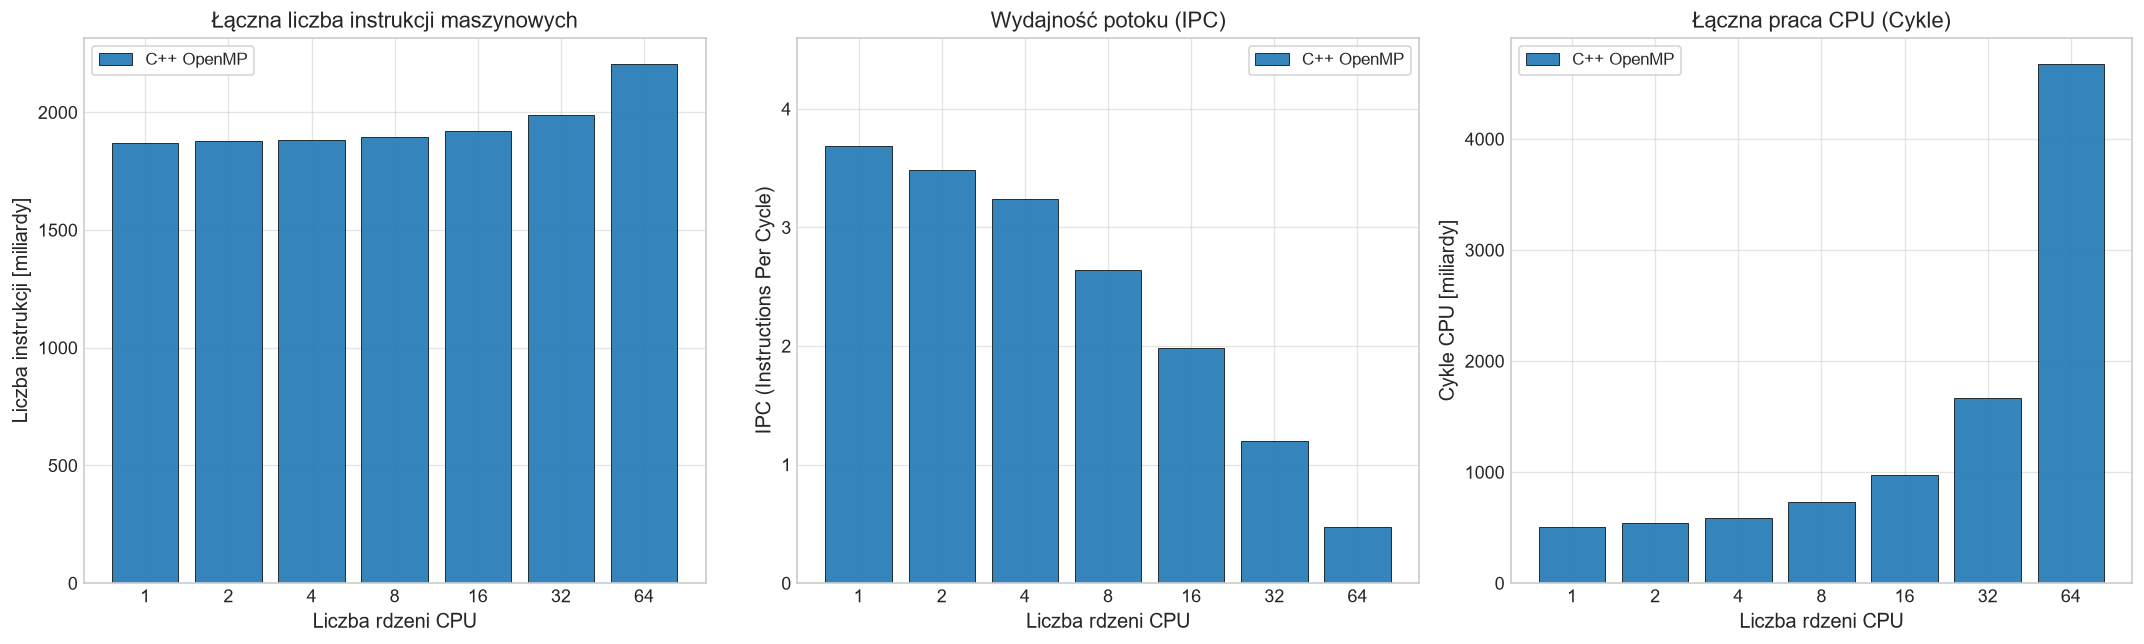

In [41]:
# Wykres 3: Metryki procesora (Instrukcje maszynowe, Cykle CPU, IPC) - Wykresy słupkowe (Grouped Bar Charts)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))

n_series = len(stats_summary)
bar_width = 0.8 / max(1, n_series)
x_base = np.arange(len(scaling_cores))

# 1. Liczba instrukcji
for i, (label, s) in enumerate(stats_summary.items()):
    x_indices = [scaling_cores.index(c) for c in s["cores"]]
    offsets = [x + (i - (n_series - 1) / 2) * bar_width for x in x_indices]
    ax1.bar(offsets, s["instructions_avg"], width=bar_width, color=s["color"], label=label, edgecolor='black', linewidth=0.5, alpha=0.9)

ax1.set_xlabel("Liczba rdzeni CPU")
ax1.set_ylabel("Liczba instrukcji [miliardy]")
ax1.set_title("Łączna liczba instrukcji maszynowych")
ax1.set_xticks(x_base)
ax1.set_xticklabels(scaling_cores)
ax1.set_ylim(bottom=0)
ax1.legend(frameon=True)

# 2. IPC
for i, (label, s) in enumerate(stats_summary.items()):
    x_indices = [scaling_cores.index(c) for c in s["cores"]]
    offsets = [x + (i - (n_series - 1) / 2) * bar_width for x in x_indices]
    ax2.bar(offsets, s["ipc_avg"], width=bar_width, color=s["color"], label=label, edgecolor='black', linewidth=0.5, alpha=0.9)

ax2.set_xlabel("Liczba rdzeni CPU")
ax2.set_ylabel("IPC (Instructions Per Cycle)")
ax2.set_title("Wydajność potoku (IPC)")
ax2.set_xticks(x_base)
ax2.set_xticklabels(scaling_cores)
max_ipc = max([max(s["ipc_avg"]) for s in stats_summary.values() if len(s["ipc_avg"]) > 0] + [4.0])
ax2.set_ylim(bottom=0, top=max_ipc * 1.15)
ax2.legend(frameon=True)

# 3. Cykle CPU
for i, (label, s) in enumerate(stats_summary.items()):
    x_indices = [scaling_cores.index(c) for c in s["cores"]]
    offsets = [x + (i - (n_series - 1) / 2) * bar_width for x in x_indices]
    ax3.bar(offsets, s["cycles_avg"], width=bar_width, color=s["color"], label=label, edgecolor='black', linewidth=0.5, alpha=0.9)

ax3.set_xlabel("Liczba rdzeni CPU")
ax3.set_ylabel("Cykle CPU [miliardy]")
ax3.set_title("Łączna praca CPU (Cykle)")
ax3.set_xticks(x_base)
ax3.set_xticklabels(scaling_cores)
ax3.set_ylim(bottom=0)
ax3.legend(frameon=True)

plt.tight_layout()
plt.show()


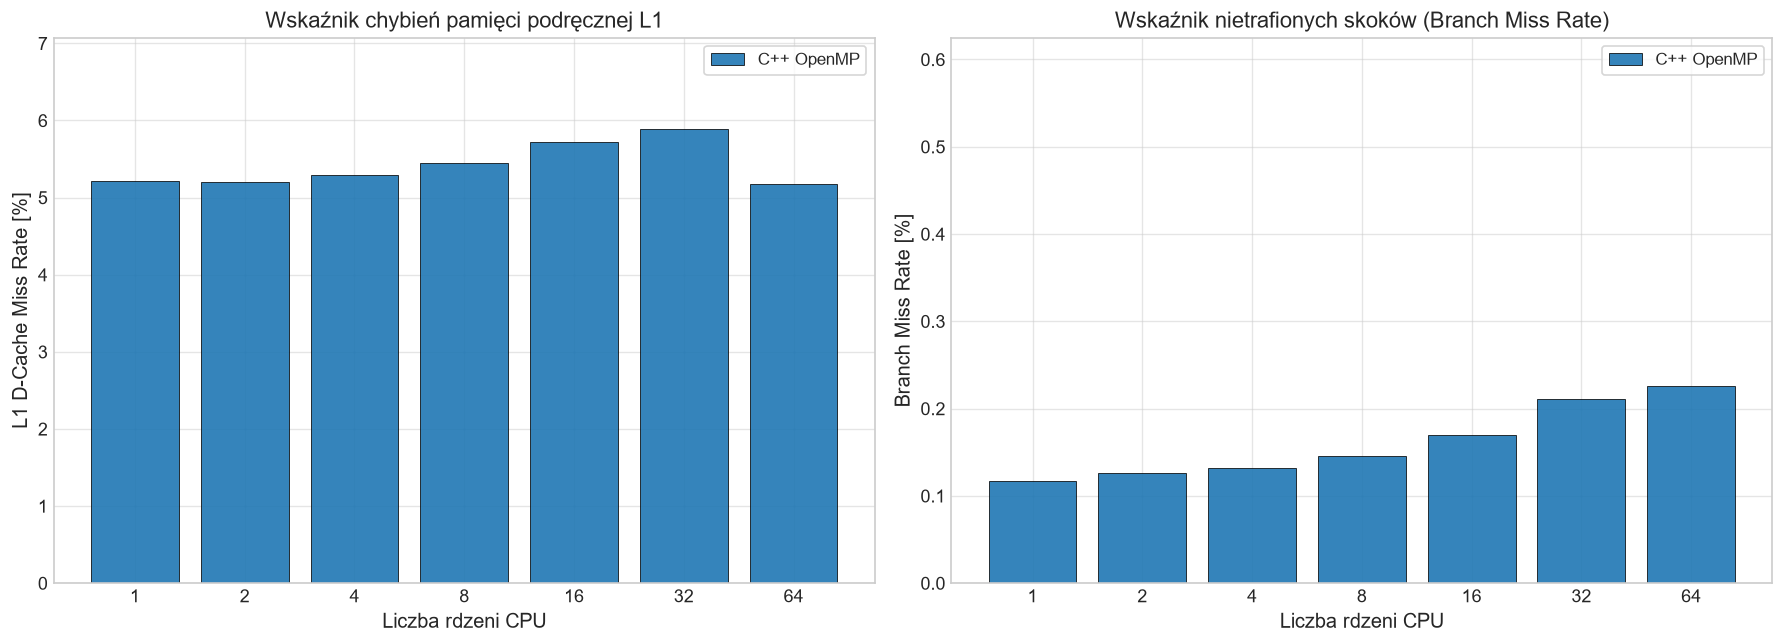

In [42]:
# Wykres 4: Pamięć podręczna L1 oraz Predykcja skoków (Branch Prediction) - Wykresy słupkowe (Grouped Bar Charts)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

n_series = len(stats_summary)
bar_width = 0.8 / max(1, n_series)
x_base = np.arange(len(scaling_cores))

# 1. L1 Cache Miss Rate
for i, (label, s) in enumerate(stats_summary.items()):
    x_indices = [scaling_cores.index(c) for c in s["cores"]]
    offsets = [x + (i - (n_series - 1) / 2) * bar_width for x in x_indices]
    ax1.bar(offsets, s["l1_miss_rate_avg"], width=bar_width, color=s["color"], label=label, edgecolor='black', linewidth=0.5, alpha=0.9)

ax1.set_xlabel("Liczba rdzeni CPU")
ax1.set_ylabel("L1 D-Cache Miss Rate [%]")
ax1.set_title("Wskaźnik chybień pamięci podręcznej L1")
ax1.set_xticks(x_base)
ax1.set_xticklabels(scaling_cores)
max_l1 = max([max(s["l1_miss_rate_avg"]) for s in stats_summary.values() if len(s["l1_miss_rate_avg"]) > 0] + [5.0])
ax1.set_ylim(bottom=0, top=max_l1 * 1.2)
ax1.legend(frameon=True)

# 2. Branch Miss Rate
for i, (label, s) in enumerate(stats_summary.items()):
    x_indices = [scaling_cores.index(c) for c in s["cores"]]
    offsets = [x + (i - (n_series - 1) / 2) * bar_width for x in x_indices]
    ax2.bar(offsets, s["branch_miss_rate_avg"], width=bar_width, color=s["color"], label=label, edgecolor='black', linewidth=0.5, alpha=0.9)

ax2.set_xlabel("Liczba rdzeni CPU")
ax2.set_ylabel("Branch Miss Rate [%]")
ax2.set_title("Wskaźnik nietrafionych skoków (Branch Miss Rate)")
ax2.set_xticks(x_base)
ax2.set_xticklabels(scaling_cores)
max_br = max([max(s["branch_miss_rate_avg"]) for s in stats_summary.values() if len(s["branch_miss_rate_avg"]) > 0] + [0.5])
ax2.set_ylim(bottom=0, top=max_br * 1.25)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()


In [43]:
# =============================================================================
# ANALIZA TEORETYCZNA HPC: PRAWO AMDAHLA, METRYKA KARPA-FLATTA I PRAWO GUSTAFSONA
# =============================================================================

amdahl_results = {}

print("=" * 100)
print("TEORETYCZNA ANALIZA SKALOWANIA HPC (DOPASOWANIE METODA NAJMNIEJSZYCH KWADRATOW)")
print("=" * 100)

for label, s in stats_summary.items():
    cores_arr = np.array(s["cores"])
    times_arr = np.array(s["time_avg"])
    
    # Dopasowanie regresji dla strefy stabilnego skalowania (p <= 32)
    valid_mask = cores_arr <= 32
    if np.sum(valid_mask) < 2:
        valid_mask = np.ones(len(cores_arr), dtype=bool)
        
    p_fit = cores_arr[valid_mask]
    t_fit = times_arr[valid_mask]
    inv_p = 1.0 / p_fit
    
    # Model Amdahla: T(p) = T_seq + T_par * (1/p)
    # Regresja liniowa: a = T_par, b = T_seq
    a, b = np.polyfit(inv_p, t_fit, 1)
    t_par = float(a)
    t_seq = float(b)
    t_total_model = t_seq + t_par
    
    f_global = (t_par / t_total_model) * 100.0
    s_global = (t_seq / t_total_model) * 100.0
    s_max_theoretical = 1.0 / (s_global / 100.0) if s_global > 0 else float('inf')
    
    # Wspolczynnik determinacji R^2
    y_pred = a * inv_p + b
    ss_res = np.sum((t_fit - y_pred)**2)
    ss_tot = np.sum((t_fit - np.mean(t_fit))**2)
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 1.0
    
    # Metryka Karpa-Flatta dla kazdego punktu: e = (1/Sp - 1/p) / (1 - 1/p)
    karp_flatt_e = []
    gustafson_sp = []
    for c, sp in zip(s["cores"], s["speedup_avg"]):
        if c > 1:
            e_val = (1.0 / sp - 1.0 / c) / (1.0 - 1.0 / c)
        else:
            e_val = 0.0
        karp_flatt_e.append(e_val)
        
        # Prawo Gustafsona (skalowanie slabe przy wzroscie rozmiaru problemu): S_scaled = p - s*(p-1)
        g_sp = c - (s_global / 100.0) * (c - 1)
        gustafson_sp.append(g_sp)
        
    amdahl_results[label] = {
        "t_par": t_par,
        "t_seq": t_seq,
        "f_global": f_global,
        "s_global": s_global,
        "s_max_theoretical": s_max_theoretical,
        "r2": r2,
        "karp_flatt_e": karp_flatt_e,
        "gustafson_sp": gustafson_sp,
        "p_fit": p_fit,
        "t_pred_all": [t_seq + t_par / c for c in scaling_cores]
    }
    
    print(f"\n>>> Implementacja: {label}")
    print(f"  - Czesc zrownoleglona (T_par):       {t_par:7.2f} s  ({f_global:.2f}%)")
    print(f"  - Czesc sekwencyjna (T_seq):         {t_seq:7.2f} s  ({s_global:.2f}%)")
    print(f"  - Ulamek zrownoleglenia (f):         {f_global:7.2f}%")
    print(f"  - Ulamek sekwencyjny (s = 1 - f):    {s_global:7.2f}%")
    print(f"  - Teoretyczny limit Amdahla (S_max): {s_max_theoretical:7.2f}x")
    print(f"  - Jakosc dopasowania modelu (R^2):    {r2:7.5f}")

# Tabela metryki Karpa-Flatta
print("\n" + "=" * 100)
print("METRYKA KARPA-FLATTA e(p) I PRAWO GUSTAFSONA S_g(p)")
print("=" * 100)
header_kf = f"{'Implementacja':<15} | {'Rdzenie':<7} | {'Czas sr [s]':<11} | {'Speedup sr':<10} | {'Karp-Flatt e':<13} | {'Gustafson S_g':<13}"
print(header_kf)
print("-" * len(header_kf))
for label, s in stats_summary.items():
    res = amdahl_results[label]
    for i, c in enumerate(s["cores"]):
        row = f"{label:<15} | {c:<7} | {s['time_avg'][i]:<11.2f} | {s['speedup_avg'][i]:<10.2f} | {res['karp_flatt_e'][i]:<13.4f} | {res['gustafson_sp'][i]:<13.2f}x"
        print(row)
    print("-" * len(header_kf))


TEORETYCZNA ANALIZA SKALOWANIA HPC (DOPASOWANIE METODA NAJMNIEJSZYCH KWADRATOW)

>>> Implementacja: C++ OpenMP
  - Czesc zrownoleglona (T_par):        134.10 s  (93.84%)
  - Czesc sekwencyjna (T_seq):            8.80 s  (6.16%)
  - Ulamek zrownoleglenia (f):           93.84%
  - Ulamek sekwencyjny (s = 1 - f):       6.16%
  - Teoretyczny limit Amdahla (S_max):   16.23x
  - Jakosc dopasowania modelu (R^2):    0.99933

METRYKA KARPA-FLATTA e(p) I PRAWO GUSTAFSONA S_g(p)
Implementacja   | Rdzenie | Czas sr [s] | Speedup sr | Karp-Flatt e  | Gustafson S_g
------------------------------------------------------------------------------------
C++ OpenMP      | 1       | 142.42      | 1.00       | 0.0000        | 1.00         x
C++ OpenMP      | 2       | 77.70       | 1.83       | 0.0911        | 1.94         x
C++ OpenMP      | 4       | 40.83       | 3.49       | 0.0489        | 3.82         x
C++ OpenMP      | 8       | 24.98       | 5.70       | 0.0576        | 7.57         x
C++ OpenMP   

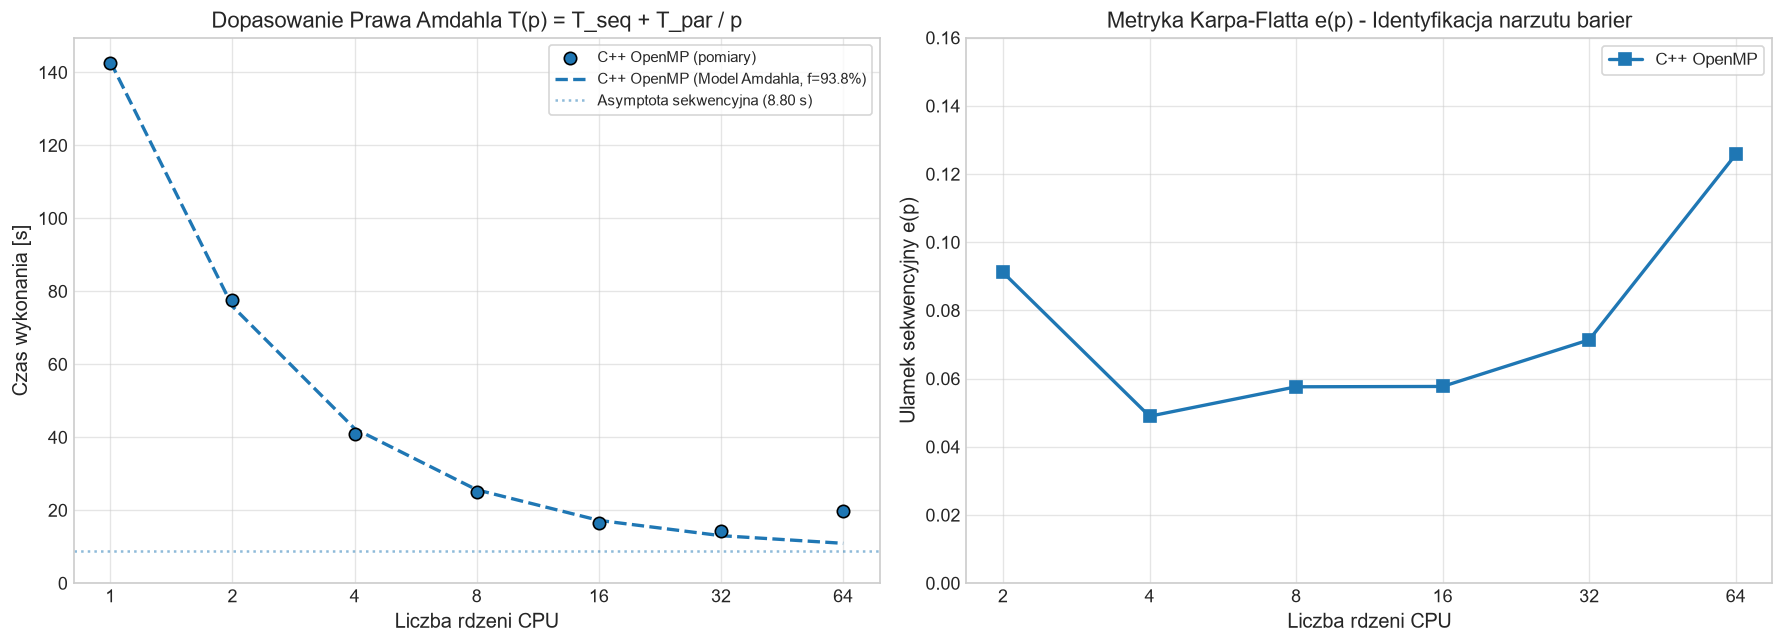

In [ ]:
# Wykres 5: Dopasowanie Prawa Amdahla oraz Analiza Metryki Karpa-Flatta
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

x_pos = {c: i for i, c in enumerate(scaling_cores)}

# Subplot 1: Dopasowanie krzywej Amdahla do czasow wykonania
for label, s in stats_summary.items():
    res = amdahl_results[label]
    xs = [x_pos[c] for c in s["cores"]]
    
    # Punkty pomiarowe
    ax1.scatter(xs, s["time_avg"], color=s["color"], s=55, edgecolors='black', label=f"{label} (pomiary)", zorder=4)
    
    # Model Amdahla wykreslony dla punktow dyskretnych
    pred_xs = [x_pos[c] for c in scaling_cores]
    ax1.plot(pred_xs, res["t_pred_all"], '--', color=s["color"], label=f"{label} (Model Amdahla, f={res['f_global']:.1f}%)", linewidth=2, zorder=3)
    
ax1.set_xlabel("Liczba rdzeni CPU")
ax1.set_ylabel("Czas wykonania [s]")
ax1.set_title("Dopasowanie Prawa Amdahla T(p) = T_seq + T_par / p")
ax1.set_xticks(range(len(scaling_cores)))
ax1.set_xticklabels(scaling_cores)
ax1.set_ylim(bottom=0)
ax1.legend(frameon=True, fontsize=9)

# Subplot 2: Metryka Karpa-Flatta e(p) (Wykrywanie narzutu barier/NUMA)
for label, s in stats_summary.items():
    res = amdahl_results[label]
    xs = [x_pos[c] for c in s["cores"] if c > 1]
    e_vals = [e for c, e in zip(s["cores"], res["karp_flatt_e"]) if c > 1]
    ax2.plot(xs, e_vals, 's-', color=s["color"], label=label, linewidth=2, markersize=7)

ax2.set_xlabel("Liczba rdzeni CPU")
ax2.set_ylabel("Ulamek sekwencyjny e(p)")
ax2.set_title("Metryka Karpa-Flatta e(p) - Identyfikacja narzutu barier")
ax2.set_xticks([x_pos[c] for c in scaling_cores if c > 1])
ax2.set_xticklabels([c for c in scaling_cores if c > 1])
ax2.set_ylim(bottom=0, top=0.16)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()
